In [1]:
import os


In [2]:
%pwd

'c:\\Users\\asdaw\\Desktop\\medical-dcgan\\research'

In [3]:
os.chdir("../")

In [4]:
%pwd

'c:\\Users\\asdaw\\Desktop\\medical-dcgan'

In [5]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class ModelTrainingConfig:

    root_dir: Path
    data_path: Path

    trained_model_dir: Path
    generated_images_dir: Path

    z_dim: int
    generator_feature_maps: int
    discriminator_feature_maps: int

    num_epochs: int
    learning_rate: float
    beta1: float
    save_image_interval: int

    batch_size: int
    image_size: int
    
    mlflow_uri: str
    all_params: dict




In [6]:
from dcGAN_image_generation.constants import *
from dcGAN_image_generation.utils.common import read_yaml, create_directories, save_json

In [7]:
from dcGAN_image_generation.constants import PARAMS_FILE_PATH
print(PARAMS_FILE_PATH.resolve())
print(PARAMS_FILE_PATH.exists())


C:\Users\asdaw\Desktop\medical-dcgan\params.yaml
True


In [8]:
%pwd

'c:\\Users\\asdaw\\Desktop\\medical-dcgan'

In [9]:
import yaml
from pathlib import Path

with open(Path("params.yaml"), "r") as f:
    data = yaml.safe_load(f)

print(data)


{'model_training': {'z_dim': 100, 'generator_feature_maps': 64, 'discriminator_feature_maps': 64, 'num_epochs': 50, 'learning_rate': 0.0002, 'beta1': 0.5, 'save_image_interval': 80}}


In [10]:
class ConfigurationManager:

    def __init__(
        self,
        config_filepath=CONFIG_FILE_PATH,
        params_filepath=PARAMS_FILE_PATH
    ):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        self.artifacts_root = ROOT_DIR / self.config.artifacts_root
        create_directories([self.artifacts_root])    
    
    def get_model_training_config(self) -> ModelTrainingConfig:
    
        config = self.config.model_training
        params = self.params.model_training
        preprocessing_config = self.config.data_preprocessing
    
        create_directories([
            config.root_dir,
            config.trained_model_dir,
            config.generated_images_dir
        ])
        
        return ModelTrainingConfig(
            root_dir=ROOT_DIR / config.root_dir,
            data_path=ROOT_DIR / preprocessing_config.data_path,
    
            trained_model_dir=ROOT_DIR / config.trained_model_dir,
            generated_images_dir=ROOT_DIR / config.generated_images_dir,
    
            z_dim=params.z_dim,
            generator_feature_maps=params.generator_feature_maps,
            discriminator_feature_maps=params.discriminator_feature_maps,
    
            num_epochs=params.num_epochs,
            learning_rate=params.learning_rate,
            beta1=params.beta1,
            save_image_interval=params.save_image_interval,
            image_size=preprocessing_config.image_size,

            batch_size=preprocessing_config.batch_size,
            
            mlflow_uri=config.mlflow_uri,

            all_params={
                "z_dim": params.z_dim,
                "gen_feature_maps": params.generator_feature_maps,
                "disc_feature_maps": params.discriminator_feature_maps,
                "learning_rate": params.learning_rate,
                "beta1": params.beta1,
                "epochs": params.num_epochs,
                "batch_size": preprocessing_config.batch_size,
                "image_size": preprocessing_config.image_size
            }
        )

    

In [11]:
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader

from dcGAN_image_generation import logger

In [12]:
 
 


class ModelTraining:
    def __init__(self, config: ModelTrainingConfig):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        logger.info(f"Using device: {self.device}")


    # -------------------------------
    # DataLoader
    # -------------------------------
    def get_dataloader(self):

        transform = transforms.Compose([
            transforms.Resize(self.config.image_size),
            transforms.CenterCrop(self.config.image_size),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])

        dataset = datasets.ImageFolder(
            root=self.config.data_path / "train",
            transform=transform
        )

        self.dataloader = DataLoader(
            dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=2,
            pin_memory=torch.cuda.is_available()
        )

        logger.info(f"Dataset loaded with {len(dataset)} images")

    # -------------------------------
    # Weight initialization
    # -------------------------------
    @staticmethod
    def weights_init(m):
        classname = m.__class__.__name__
        if classname.find("Conv") != -1:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif classname.find("BatchNorm") != -1:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

    # -------------------------------
    # Generator
    # -------------------------------
    def build_generator(self):

        nz = self.config.z_dim
        ngf = self.config.generator_feature_maps
        nc = 3

        self.netG = nn.Sequential(

            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        ).to(self.device)

        self.netG.apply(self.weights_init)

    # -------------------------------
    # Discriminator
    # -------------------------------
    def build_discriminator(self):

        ndf = self.config.discriminator_feature_maps
        nc = 3

        self.netD = nn.Sequential(

            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        ).to(self.device)

        self.netD.apply(self.weights_init)

    # -------------------------------
    # Training
    # -------------------------------
    def train(self):

        criterion = nn.BCELoss()

        fixed_noise = torch.randn(64, self.config.z_dim, 1, 1, device=self.device)

        real_label = 1.
        fake_label = 0.

        optimizerD = optim.Adam(
            self.netD.parameters(),
            lr=self.config.learning_rate,
            betas=(self.config.beta1, 0.999)
        )

        optimizerG = optim.Adam(
            self.netG.parameters(),
            lr=self.config.learning_rate,
            betas=(self.config.beta1, 0.999)
        )

        logger.info("Starting Training Loop...")

        for epoch in range(self.config.num_epochs):
            for i, data in enumerate(self.dataloader):

                ############################
                # Train Discriminator
                ############################
                self.netD.zero_grad()

                real_images = data[0].to(self.device)
                b_size = real_images.size(0)

                label = torch.full((b_size,), real_label, device=self.device)

                output = self.netD(real_images).view(-1)
                errD_real = criterion(output, label)
                errD_real.backward()

                noise = torch.randn(b_size, self.config.z_dim, 1, 1, device=self.device)
                fake = self.netG(noise)

                label.fill_(fake_label)

                output = self.netD(fake.detach()).view(-1)
                errD_fake = criterion(output, label)
                errD_fake.backward()

                optimizerD.step()

                ############################
                # Train Generator
                ############################
                self.netG.zero_grad()

                label.fill_(real_label)

                output = self.netD(fake).view(-1)
                errG = criterion(output, label)
                errG.backward()

                optimizerG.step()

                if i % self.config.save_image_interval == 0:
                    with torch.no_grad():
                        fake = self.netG(fixed_noise).detach().cpu()

                    utils.save_image(
                        fake,
                        self.config.generated_images_dir / f"epoch_{epoch}_iter_{i}.png",
                        normalize=True
                    )

            logger.info(f"Epoch [{epoch+1}/{self.config.num_epochs}] completed")

        torch.save(
            self.netG.state_dict(),
            Path(self.config.trained_model_dir) / "generator.pth"
        )

        torch.save(
            self.netD.state_dict(),
            Path(self.config.trained_model_dir) / "discriminator.pth"
        )

        logger.info("Models saved successfully")
        
        return errG.item(), (errD_real + errD_fake).item()
        
    
   


In [13]:
import mlflow
import mlflow.pytorch
from urllib.parse import urlparse

In [14]:
 
 

try:
    # ================================
    # Load config
    # ================================
    config = ConfigurationManager()
    training_config = config.get_model_training_config()

    # ================================
    # DagsHub authentication
    # ================================
    os.environ["MLFLOW_TRACKING_USERNAME"] =  os.getenv("MLFLOW_TRACKING_USERNAME")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

    mlflow.set_tracking_uri(training_config.mlflow_uri)
    mlflow.set_experiment("DCGAN_Chest_Xray")

    # ================================
    # Start MLflow run
    # ================================
    with mlflow.start_run():

        # 🔹 log all hyperparameters
        mlflow.log_params(training_config.all_params)

        # ================================
        # Training
        # ================================
        trainer = ModelTraining(config=training_config)

        trainer.get_dataloader()
        trainer.build_generator()
        trainer.build_discriminator()

        final_G_loss, final_D_loss = trainer.train()

        # ================================
        # Log metrics
        # ================================
        mlflow.log_metric("G_loss", final_G_loss)
        mlflow.log_metric("D_loss", final_D_loss)

        # ================================
        # Log generated images
        # ================================
        mlflow.log_artifacts(
            str(training_config.generated_images_dir),
            artifact_path="generated_images"
        )

        # ================================
        # Log models
        # ================================
        mlflow.pytorch.log_model(trainer.netG, "generator")
        mlflow.pytorch.log_model(trainer.netD, "discriminator")

except Exception as e:
    raise e


[2026-02-20 14:42:34,588: INFO: common]: yaml file loaded: config\config.yaml]
[2026-02-20 14:42:34,593: INFO: common]: yaml file loaded: params.yaml]
[2026-02-20 14:42:34,594: INFO: common]: created directory at: C:\Users\asdaw\Desktop\medical-dcgan\artifacts]
[2026-02-20 14:42:34,595: INFO: common]: created directory at: artifacts/model_training]
[2026-02-20 14:42:34,597: INFO: common]: created directory at: artifacts/model_training/models]
[2026-02-20 14:42:34,598: INFO: common]: created directory at: artifacts/model_training/generated_images]


[2026-02-20 14:42:38,531: INFO: 2964188262]: Using device: cuda]
[2026-02-20 14:42:38,764: INFO: 2964188262]: Dataset loaded with 5216 images]
[2026-02-20 14:42:39,607: INFO: 2964188262]: Starting Training Loop...]
[2026-02-20 14:43:22,334: INFO: 2964188262]: Epoch [1/50] completed]
[2026-02-20 14:44:09,215: INFO: 2964188262]: Epoch [2/50] completed]
[2026-02-20 14:44:54,722: INFO: 2964188262]: Epoch [3/50] completed]
[2026-02-20 14:45:42,344: INFO: 2964188262]: Epoch [4/50] completed]
[2026-02-20 14:46:30,592: INFO: 2964188262]: Epoch [5/50] completed]
[2026-02-20 14:47:18,046: INFO: 2964188262]: Epoch [6/50] completed]
[2026-02-20 14:48:06,020: INFO: 2964188262]: Epoch [7/50] completed]
[2026-02-20 14:48:54,374: INFO: 2964188262]: Epoch [8/50] completed]
[2026-02-20 14:49:42,988: INFO: 2964188262]: Epoch [9/50] completed]
[2026-02-20 14:50:31,589: INFO: 2964188262]: Epoch [10/50] completed]
[2026-02-20 14:51:19,552: INFO: 2964188262]: Epoch [11/50] completed]
[2026-02-20 14:52:07,200

2026/02/20 15:23:04 WARNING mlflow.utils.requirements_utils: Found torch version (2.2.2+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.2.2' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/20 15:23:13 WARNING mlflow.utils.requirements_utils: Found torch version (2.2.2+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.2.2' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
c:\Users\asdaw\Desktop\medical-dcgan\dcgan_proj\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
2026/02/20 15:23:47 WARNING mlflow.utils.require

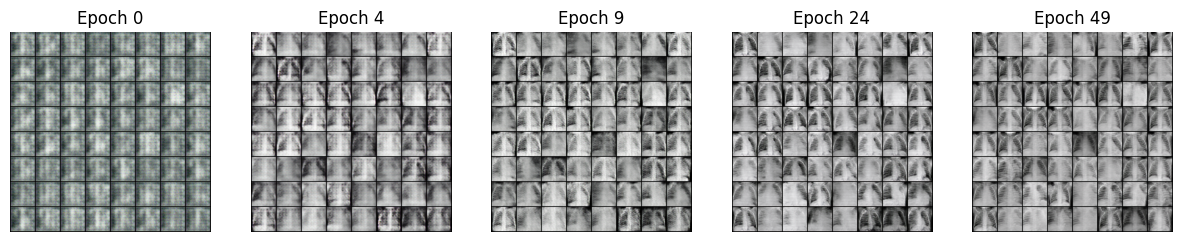

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

img_dir = Path("artifacts/model_training/generated_images")

epochs_to_show = [0, 4, 9, 24, 49]   # change based on what exists

plt.figure(figsize=(15,4))

for i, ep in enumerate(epochs_to_show):
    img = Image.open(img_dir / f"epoch_{ep}_iter_80.png")
    plt.subplot(1, len(epochs_to_show), i+1)
    plt.imshow(img)
    plt.title(f"Epoch {ep}")
    plt.axis("off")

plt.show()

[2026-02-20 16:06:43,115: INFO: common]: yaml file loaded: config\config.yaml]
[2026-02-20 16:06:43,117: INFO: common]: yaml file loaded: params.yaml]
[2026-02-20 16:06:43,118: INFO: common]: created directory at: C:\Users\asdaw\Desktop\medical-dcgan\artifacts]
[2026-02-20 16:06:43,120: INFO: common]: created directory at: artifacts/model_training]
[2026-02-20 16:06:43,121: INFO: common]: created directory at: artifacts/model_training/models]
[2026-02-20 16:06:43,122: INFO: common]: created directory at: artifacts/model_training/generated_images]
[2026-02-20 16:06:43,122: INFO: 2964188262]: Using device: cuda]


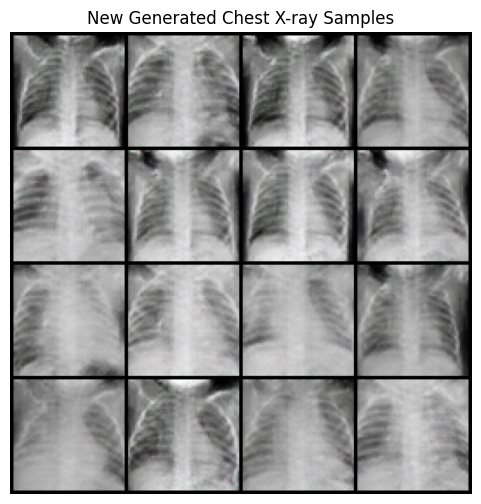

In [20]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
from torchvision.utils import save_image
from dcGAN_image_generation.config.configuration import ConfigurationManager
 


# ----------------------------------
# 1️⃣ Device
# ----------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------------
# 2️⃣ Load config
# ----------------------------------
config = ConfigurationManager()
training_config = config.get_model_training_config()


# ----------------------------------
# 3️⃣ Rebuild Generator
# ----------------------------------
trainer = ModelTraining(config=training_config)
trainer.build_generator()

trainer.netG.load_state_dict(
    torch.load(
        training_config.trained_model_dir / "generator.pth",
        map_location=device
    )
)

trainer.netG.eval()


# ----------------------------------
# 4️⃣ Generate NEW images
# ----------------------------------
noise = torch.randn(16, training_config.z_dim, 1, 1, device=device)

with torch.no_grad():
    fake_images = trainer.netG(noise).cpu()

 

save_image(fake_images, "new_generated_samples.png", nrow=4, normalize=True)

# ----------------------------------
# 5️⃣ Show grid
# ----------------------------------
grid = make_grid(fake_images, nrow=4, normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.title("New Generated Chest X-ray Samples")
plt.show()

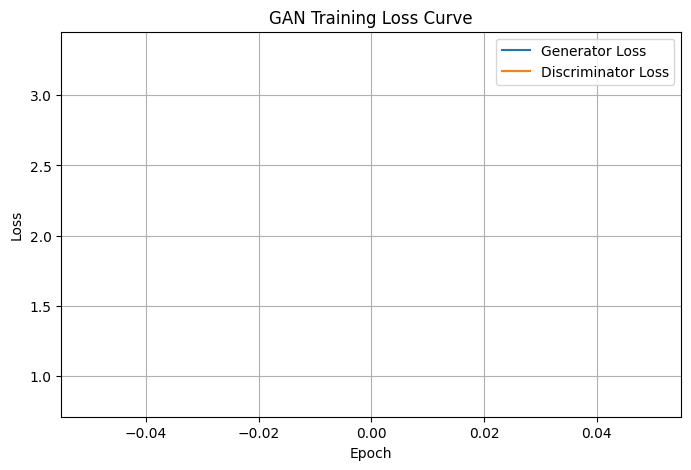

In [21]:
import mlflow
mlflow.set_tracking_uri("https://dagshub.com/indrayanibhujade378/medical-dcgan.mlflow")

runs = mlflow.search_runs(order_by=["start_time DESC"])
runs[["run_id", "metrics.G_loss", "metrics.D_loss"]]

from mlflow.tracking import MlflowClient
import pandas as pd

run_id = runs.iloc[0]["run_id"]   # latest run

client = MlflowClient()

g_history = client.get_metric_history(run_id, "G_loss")
d_history = client.get_metric_history(run_id, "D_loss")


g_df = pd.DataFrame([(m.step, m.value) for m in g_history],
                    columns=["epoch", "G_loss"])

d_df = pd.DataFrame([(m.step, m.value) for m in d_history],
                    columns=["epoch", "D_loss"])




import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(g_df["epoch"], g_df["G_loss"], label="Generator Loss")
plt.plot(d_df["epoch"], d_df["D_loss"], label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
print(g_df)
print(d_df)

   epoch    G_loss
0      0  3.328065
   epoch   D_loss
0      0  0.83411
